# Customer Purchase analysis using **Clustering** with *k-means*
### Author: Phemelo Tebeila

### Objective
This project analyzes customer purchasing patterns using clustering algorithms to identify distinct customer segments for targeted marketing strategies.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

*Loading the dataset and viewing basic information about aur dataset*

In [67]:
df = pd.read_csv('shopping_trends_updated.csv')

print(df.head())
print(df.info())
print(df.describe())

print("The shape of the dataset: ", df.shape)

   Customer Id  Age Gender Item Purchased  Category  Purchase Amount (Usd)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

*Data cleaning and preprocessing*

In [68]:
df.isnull().sum()
df= df.drop_duplicates()

df["Gender"] = df["Gender"].str.title()

df.to_csv("clean_data.csv", index=False) 

*Exploratory data analysis*

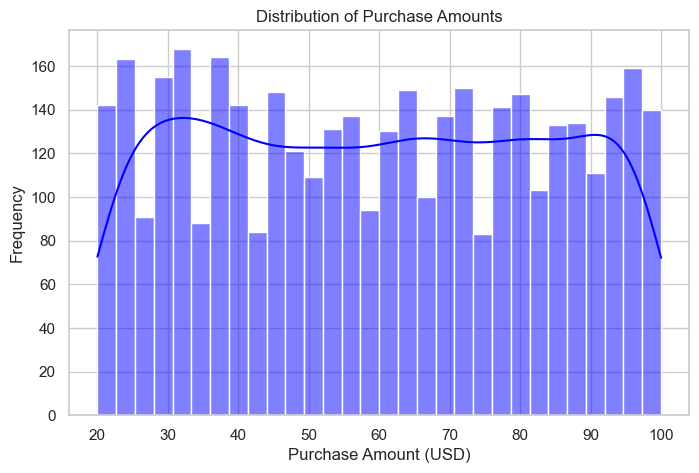

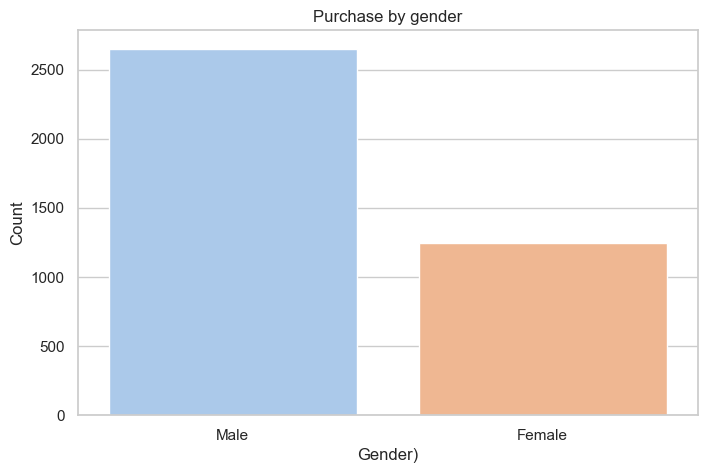

C:\Users\Tebeila\AppData\Local\Temp\ipykernel_6384\3178387956.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='coolwarm',legend=False)


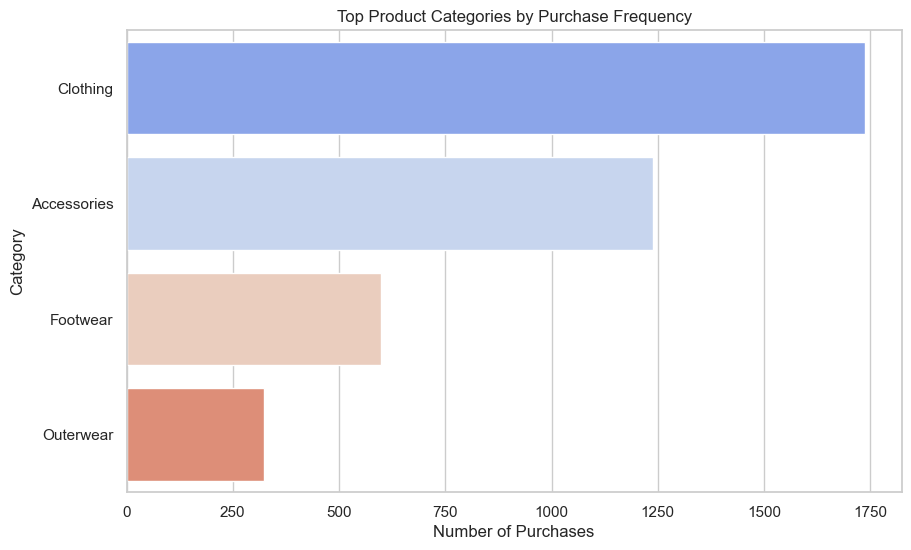

C:\Users\Tebeila\AppData\Local\Temp\ipykernel_6384\3178387956.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Payment Method', y='Purchase Amount (Usd)', data=df, palette='Set3' )


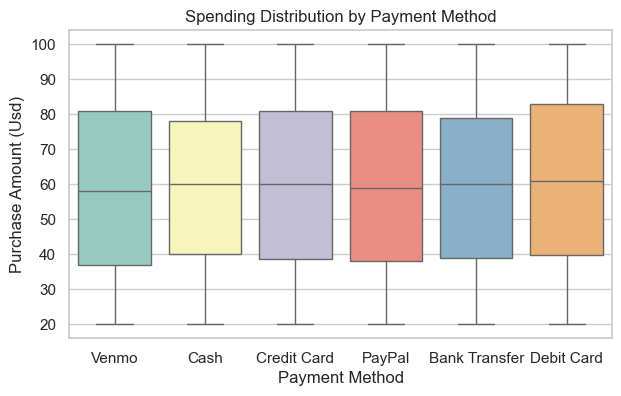

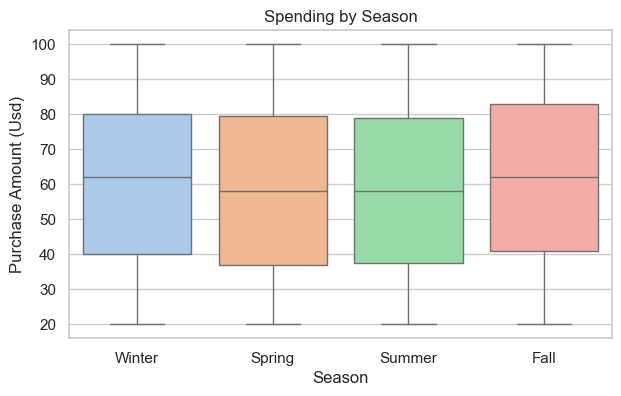

In [69]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5) 
plt.show()

# Distribution of Purchase Amounts
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase Amount (Usd)'], bins=30, kde=True, color='blue')
plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency") # Shows how many people fall into the purchase amount category( e.g about 145 people spent 40usd)
plt.show()

# Purchases by gender
plt.figure(figsize=(8,5))
sns.countplot(x='Gender',hue= 'Gender', data=df, palette='pastel', legend=False)
plt.title("Purchase by gender")
plt.xlabel("Gender)")
plt.ylabel("Count") # Shows how many people fall into the purchase amount category( e.g about 145 people spent 40usd)
plt.show()

#Top Product Categories by Purchase Frequency
plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='coolwarm',legend=False)
plt.title("Top Product Categories by Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()

#Spending by Payment Method
plt.figure(figsize=(7,4))
sns.boxplot(x='Payment Method', y='Purchase Amount (Usd)', data=df, palette='Set3' )
plt.title("Spending Distribution by Payment Method")
plt.show()

#Seasonal Spending Patterns
plt.figure(figsize=(7,4))
sns.boxplot(x='Season',hue='Season', y='Purchase Amount (Usd)', data=df, palette='pastel',legend=False)
plt.title("Spending by Season")
plt.show()


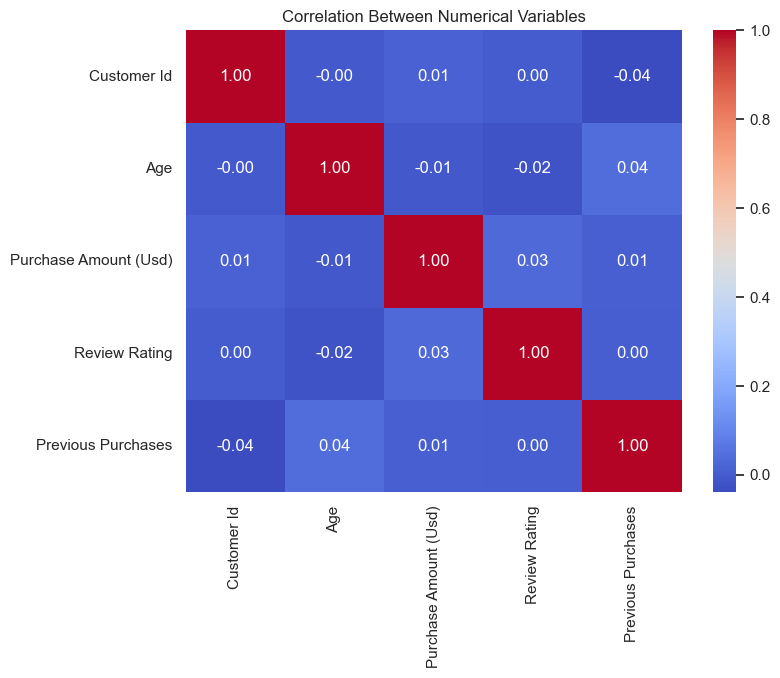

In [70]:
# Correlation between numeric values
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numerical Variables")
plt.show()


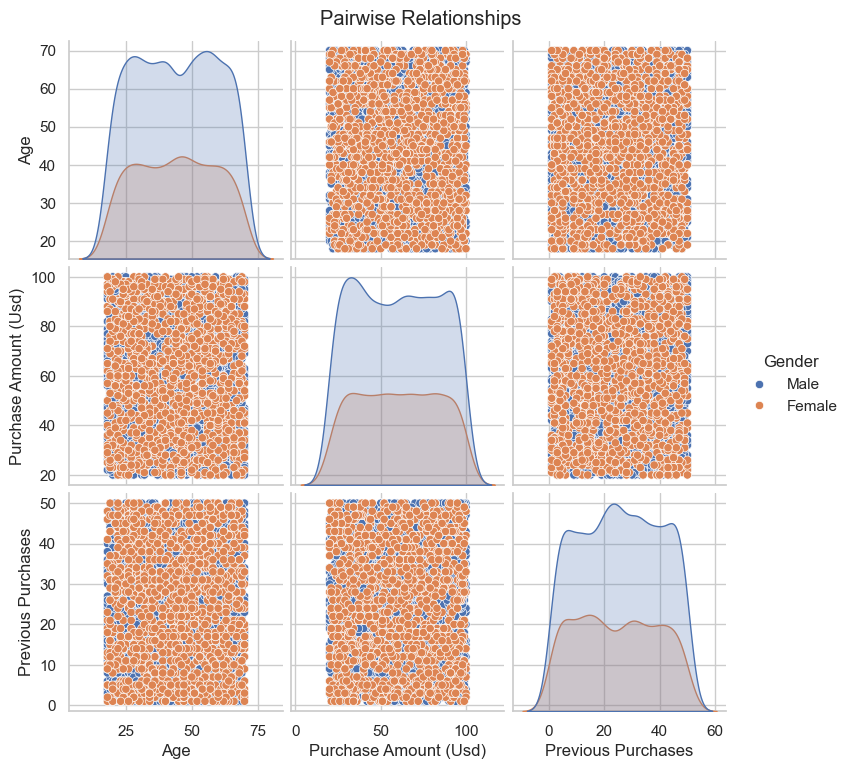

In [71]:
sns.pairplot(df, vars=['Age', 'Purchase Amount (Usd)', 'Previous Purchases'], hue='Gender')
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

*Feature engineering*

In [72]:
df = df.drop(columns=['CustomerID'], errors='ignore')
df_encoded= pd.get_dummies(df, drop_first=True)

df_encoded['Previous Purchases'] = np.log1p(df_encoded['Previous Purchases'])
df_encoded['Purchase Amount (Usd)'] = np.log1p(df_encoded['Purchase Amount (Usd)'])

#Scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)



*Pricipal Component Analysis*

In [53]:
pca = PCA().fit(scaled_data)
explained = np.cumsum(pca.explained_variance_ratio_)

# Applying PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.85)  
pca_data = pca.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("Reduced shape:", pca_data.shape)

Original shape: (3900, 131)
Reduced shape: (3900, 96)


*K-means Clustering*

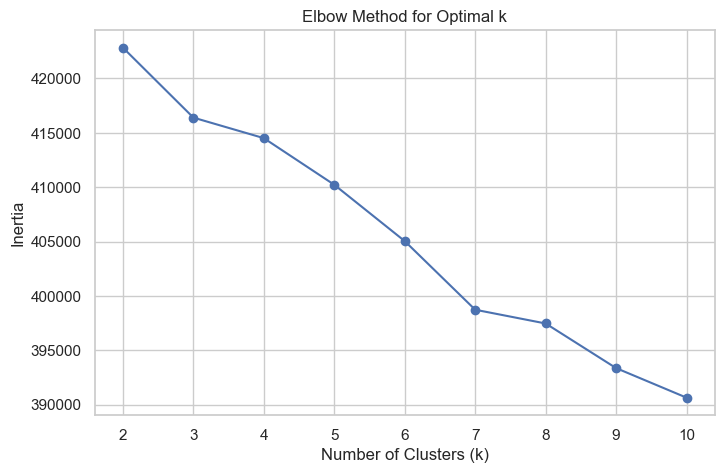

In [54]:
# Test different numbers of clusters
inertia = []  # sum of squared distances to cluster centers
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)  # or scaled_data if you skipped PCA
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [55]:
#Using silhouette score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data) 
    score = silhouette_score(pca_data, labels)
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.0320
k=3, silhouette score=0.0322
k=4, silhouette score=0.0226
k=5, silhouette score=0.0214
k=6, silhouette score=0.0258
k=7, silhouette score=0.0307
k=8, silhouette score=0.0317
k=9, silhouette score=0.0377
k=10, silhouette score=0.0398


In [56]:
optimal_k = 3  # example
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to your original dataset
df['Cluster'] = clusters

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         Customer Id        Age  Purchase Amount (Usd)  Review Rating  \
Cluster                                                                 
0        1959.759599  44.442404              60.255426       3.790651   
1        2783.993096  43.887945              60.320234       3.752310   
2         839.770804  44.150212              58.818759       3.729619   

         Previous Purchases  
Cluster                      
0                 25.232053  
1                 25.093468  
2                 25.744711  


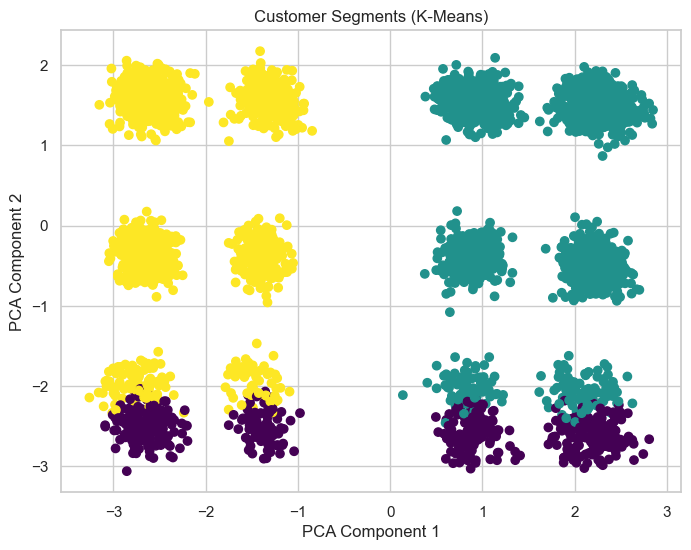

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title('Customer Segments (K-Means)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [61]:
# Example mapping based on interpretation
cluster_labels = {
    0: 'High Spender',
    1: 'Frequent Buyer',
    2: 'Low Spender'
}

# Assign labels
df['Customer Segment'] = df['Cluster'].map(cluster_labels)

df['Customer Segment'].value_counts()

Customer Segment
Frequent Buyer    1883
Low Spender       1418
High Spender       599
Name: count, dtype: int64

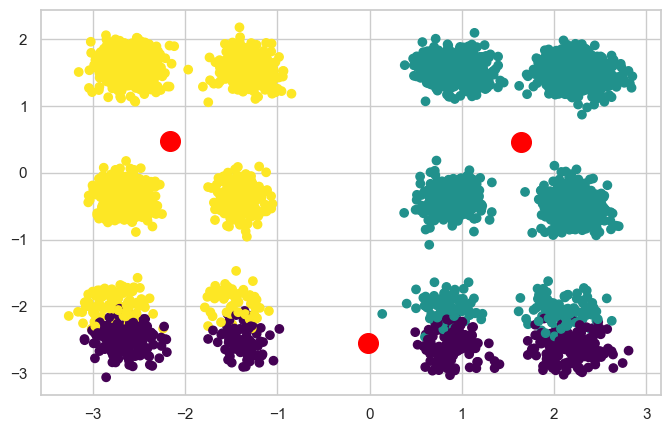

In [62]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans.labels_, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='o')

### Cluster analysis


**Cluster 0 – Frequent Buyers (1,883 customers)**

*Profile:*

Average Age: ~44 years

Average Purchase Amount: ~$60.26

Average Review Rating: ~3.79

Average Previous Purchases: ~25

These customers purchase frequently and have moderately high spending. They seem engaged and loyal, given the number of previous purchases and their consistent review ratings.

*Marketing Recommendations:*

Offer loyalty programs or membership perks to retain engagement.
Introduce bundle offers or subscription services to increase purchase value.
Send personalized product recommendations based on their purchase history.

**Cluster 1 – Low Spenders (1,418 customers)**

*Profile:*
Average Age: ~43.9 years
Average Purchase Amount: ~$60.32
Average Review Rating: ~3.75
Average Previous Purchases: ~25

This cluster has similar purchase frequency to frequent buyers but tends to spend less per transaction or purchases lower-value items.

*Marketing Recommendations:*

Offer discounts, promotions, and coupons to encourage higher spending.
Run awareness campaigns highlighting product value.
Encourage engagement through loyalty points or rewards for incremental spending.

**Cluster 2 – High Spenders (599 customers)**

*Profile:*

Average Age: ~44.2 years

Average Purchase Amount: ~$58.82

Average Review Rating: ~3.73

Average Previous Purchases: ~25.74


These customers make fewer transactions but spend more per purchase than low spenders. They are likely premium buyers who value higher-priced or exclusive products.

*Marketing Recommendations:*

Offer premium services and VIP membership programs.

Send exclusive product launches or early access promotions.

Provide personalized communication and high-touch customer service to maintain loyalty.

**Overall Observations**

* Average Age is similar across clusters (~44 years), indicating no strong age segmentation needed.

* Review ratings are relatively close (~3.73–3.79), showing consistent satisfaction.

* Cluster sizes vary: most customers are frequent buyers, followed by low spenders, and fewer high spenders.

### Data analysis- EDA INSIGHT
The dataset contains 3,900 customer records with 18 features, including demographic information, purchase behavior, and product details. Key numeric variables include:

* Purchase Amount (Usd) – amount spent per transaction

* Frequency Of Purchases – how often a customer buys

* Previous Purchases – cumulative purchase count

* Review Rating – customer satisfaction

#### Based on the exploratory data analysis of the customer purchasing dataset:

**Purchase Amounts:**

Most customers spend between $30 to $40 per transaction, indicating a moderate spending range for the majority of the customer base.

This suggests that promotions or marketing campaigns targeted around this price range could appeal to the largest group of customers.

**Gender Differences:**

Male customers tend to spend slightly more than females on average.

This indicates potential for gender-specific marketing strategies or product recommendations.

**Top Product Categories:**

Clothing is the most purchased category, followed by Accessories and Footwear, while Outerwear has the lowest sales.

Marketing campaigns could prioritize clothing and accessories, while outerwear could be promoted during seasonal campaigns (e.g., winter promotions).

**Payment Methods:**

The debit card is the most commonly used payment method.

Although differences between payment methods are small, knowing that debit card usage dominates can help optimize checkout experiences and payment promotions.

**Seasonal Trends:**

Winter and fall show higher average purchase amounts compared to spring and summer.

This highlights a seasonal effect on spending, suggesting targeted campaigns during these high-spending seasons could maximize revenue.

#### Marketing Strategies

* Target campaigns around the $30–$40 spending range to capture the majority of customers.

* Consider gender-specific promotions, as males tend to spend slightly more.

* Prioritize clothing and accessories in marketing campaigns.

* Offer seasonal promotions in winter and fall to leverage higher spending periods.

* Optimize payment methods, focusing on debit card users for smoother transactions.

